In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("global_web_traffic_dataset.csv")
df.head()
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   visit_id              2000 non-null   int64 
 1   date                  2000 non-null   object
 2   country               2000 non-null   object
 3   traffic_source        2000 non-null   object
 4   device_type           2000 non-null   object
 5   browser               2000 non-null   object
 6   page                  2000 non-null   object
 7   session_duration_sec  2000 non-null   int64 
 8   pages_viewed          2000 non-null   int64 
 9   bounce                2000 non-null   int64 
 10  conversion            2000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 172.0+ KB


,visit_id,session_duration_sec,pages_viewed,bounce,conversion
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,930.600500,7.42650,0.302500,0.100500
std,577.494589,513.915695,4.00395,0.459455,0.300741
min,1.000000,10.000000,1.00000,0.000000,0.000000
25%,500.750000,487.750000,4.00000,0.000000,0.000000
50%,1000.500000,952.000000,7.00000,0.000000,0.000000
75%,1500.250000,1382.500000,11.00000,1.000000,0.000000
max,2000.000000,1799.000000,14.00000,1.000000,1.000000


In [7]:
df.isnull().sum()

visit_id                0
date                    0
country                 0
traffic_source          0
device_type             0
browser                 0
page                    0
session_duration_sec    0
pages_viewed            0
bounce                  0
conversion              0
dtype: int64

In [9]:
df=df.dropna()
df["session_duration_sec"].fillna(df["session_duration_sec"].mean(), 
                                  inplace=True)

C:\Users\Mawhiba Khan Ameera\AppData\Local\Temp\ipykernel_26616\439816877.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["session_duration_sec"].fillna(df["session_duration_sec"].mean(),


In [10]:
df=df.drop_duplicates()

In [11]:
df["date"]=pd.to_datetime(df["date"])

In [12]:
df["device_type"]=df["device_type"].str.lower()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   visit_id              2000 non-null   int64 
 1   date                  2000 non-null   object
 2   country               2000 non-null   object
 3   traffic_source        2000 non-null   object
 4   device_type           2000 non-null   object
 5   browser               2000 non-null   object
 6   page                  2000 non-null   object
 7   session_duration_sec  2000 non-null   int64 
 8   pages_viewed          2000 non-null   int64 
 9   bounce                2000 non-null   int64 
 10  conversion            2000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 172.0+ KB


In [15]:
df.describe()

,visit_id,session_duration_sec,pages_viewed,bounce,conversion
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,930.600500,7.42650,0.302500,0.100500
std,577.494589,513.915695,4.00395,0.459455,0.300741
min,1.000000,10.000000,1.00000,0.000000,0.000000
25%,500.750000,487.750000,4.00000,0.000000,0.000000
50%,1000.500000,952.000000,7.00000,0.000000,0.000000
75%,1500.250000,1382.500000,11.00000,1.000000,0.000000
max,2000.000000,1799.000000,14.00000,1.000000,1.000000


In [16]:
df["conversion"].mean()

np.float64(0.1005)

In [17]:
df["bounce"].mean()

np.float64(0.3025)

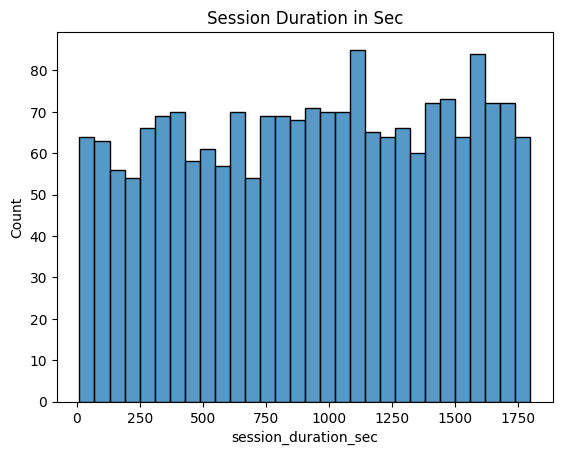

In [19]:
sns.histplot(df["session_duration_sec"],bins=30)
plt.title("Session Duration in Sec")
plt.show()

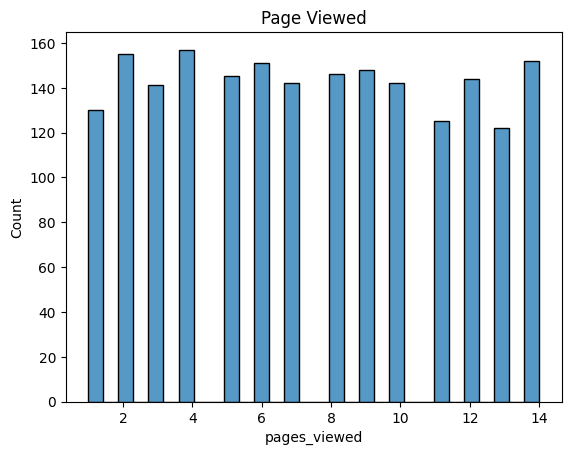

In [22]:
sns.histplot(df["pages_viewed"], bins=30)
plt.title("Page Viewed")
plt.show()

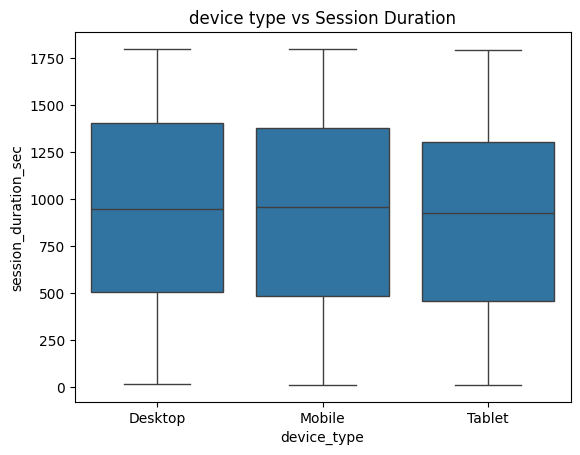

In [24]:
sns.boxplot(x="device_type", y="session_duration_sec",data=df)
plt.title("device type vs Session Duration")
plt.show()

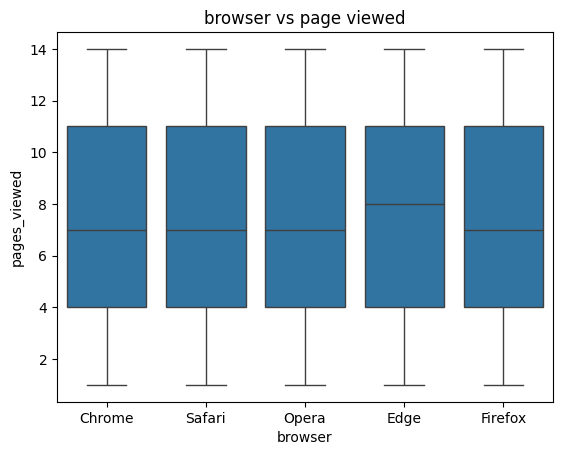

In [26]:
sns.boxplot(x="browser",y="pages_viewed",data=df)
plt.title("browser vs page viewed")
plt.show()

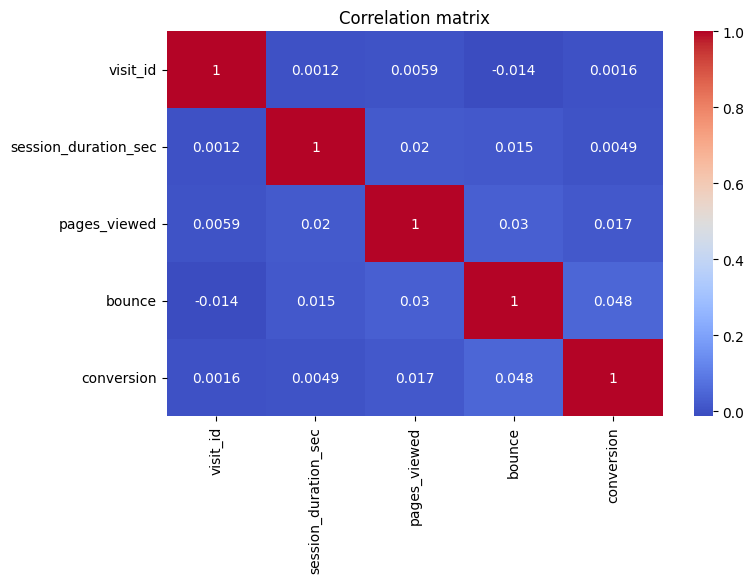

In [27]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()


Correlation matrix show very weak linear relationship between variable indicating that user behaviour is not directly depend on any linear relation. 

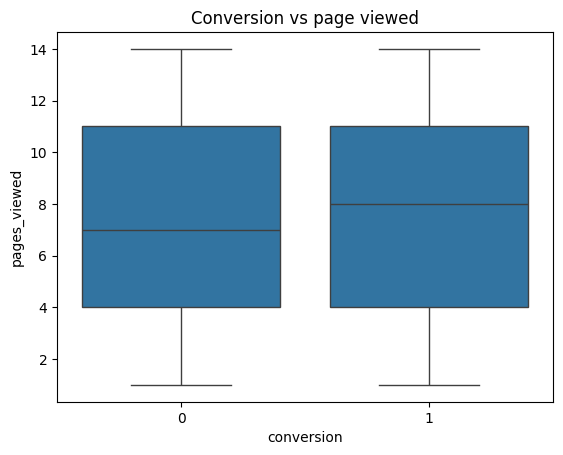

In [28]:
sns.boxplot(x="conversion",y="pages_viewed",data=df)
plt.title("Conversion vs page viewed")
plt.show()

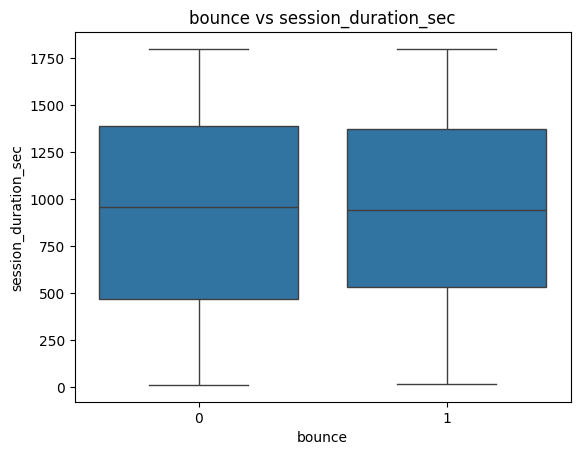

In [29]:
sns.boxplot(x="bounce",y="session_duration_sec",data=df)
plt.title("bounce vs session_duration_sec")
plt.show()

# Hypothesis Testing:
Which browser is most used?

In [30]:
import pandas as pd
from scipy.stats import chi2_contingency

browser_counts = df["browser"].value_counts()

chi2, p, dof, expected = chi2_contingency([browser_counts.values])

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 0.0
p-value: 1.0


Device type affects session duration?

In [31]:
from scipy import stats

mobile = df[df["device_type"]=="Mobile"]["session_duration_sec"]
desktop = df[df["device_type"]=="Desktop"]["session_duration_sec"]
tablet = df[df["device_type"]=="Tablet"]["session_duration_sec"]

f_stat, p_value = stats.f_oneway(mobile, desktop, tablet)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 0.7020629727380541
p-value: 0.49568418842216977


More pages viewed → higher conversion?

In [33]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["pages_viewed"], df["conversion"])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.016731148216979422
p-value: 0.45456617174340047


ML Model Evaluation

In [36]:
import pandas as pd

# Target
y = df["conversion"]

# Features 
X = df[[
    "session_duration_sec",
    "pages_viewed",
    "bounce"
]]

In [37]:
df_encoded = pd.get_dummies(df, columns=[
    "device_type",
    "browser",
    "country",
    "traffic_source"
])

In [38]:
X = df_encoded.drop(["conversion", "visit_id", "date", "page"], axis=1)
y = df_encoded["conversion"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [47]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       360
           1       0.00      0.00      0.00        40

    accuracy                           0.90       400
   macro avg       0.45      0.50      0.47       400
weighted avg       0.81      0.90      0.85       400



c:\Users\Mawhiba Khan Ameera\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mawhiba Khan Ameera\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mawhiba Khan Ameera\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [43]:
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       360
           1       0.00      0.00      0.00        40

    accuracy                           0.90       400
   macro avg       0.45      0.50      0.47       400
weighted avg       0.81      0.90      0.85       400



c:\Users\Mawhiba Khan Ameera\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mawhiba Khan Ameera\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mawhiba Khan Ameera\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

In [44]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric="logloss")
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [45]:
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGB Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       360
           1       0.17      0.03      0.04        40

    accuracy                           0.89       400
   macro avg       0.53      0.51      0.49       400
weighted avg       0.83      0.89      0.85       400



In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_scores(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

In [51]:
log_scores = get_scores(log_model, X_test, y_test)
rf_scores = get_scores(rf_model, X_test, y_test)
xgb_scores = get_scores(xgb_model, X_test, y_test)

c:\Users\Mawhiba Khan Ameera\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mawhiba Khan Ameera\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [52]:
import pandas as pd

comparison = pd.DataFrame([
    log_scores,
    rf_scores,
    xgb_scores
], index=["Logistic Regression", "Random Forest", "XGBoost"])

print(comparison)

                     Accuracy  Precision  Recall        F1
Logistic Regression      0.90   0.000000   0.000  0.000000
Random Forest            0.90   0.000000   0.000  0.000000
XGBoost                  0.89   0.166667   0.025  0.043478


<Axes: >

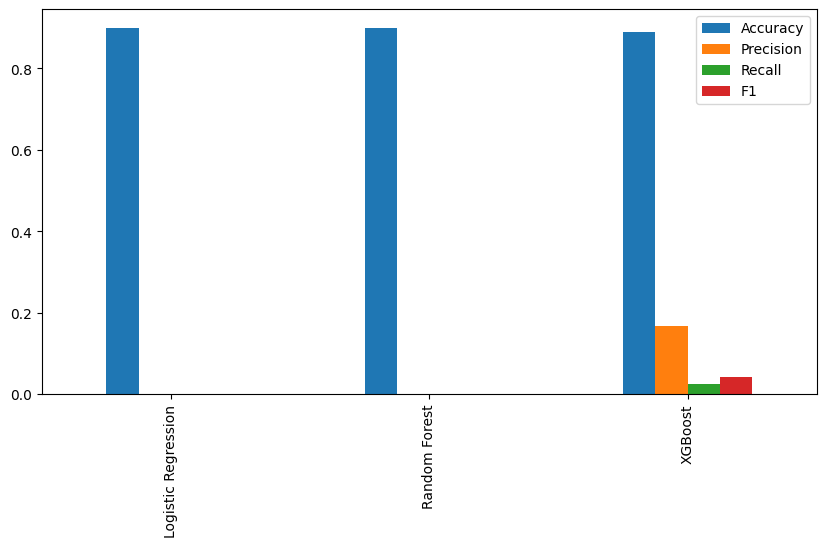

In [53]:
comparison.plot(kind="bar", figsize=(10,5))

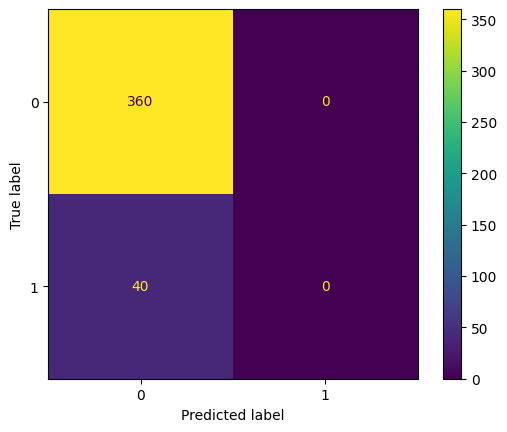

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# best model choose 
y_pred = log_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

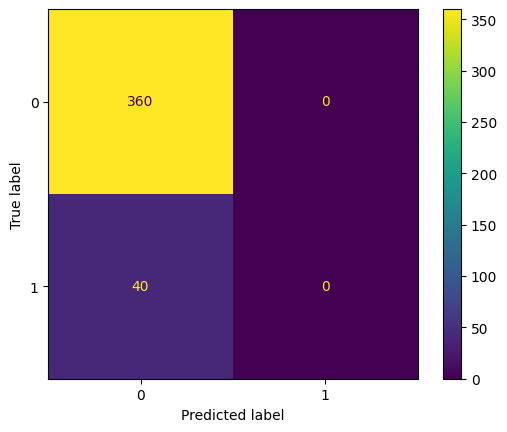

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# best model choose 
y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

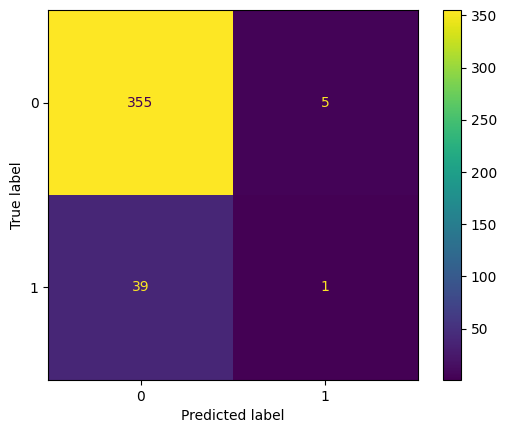

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# best model choose 
y_pred = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.5222916666666667


In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.499375


In [62]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.5462847222222222


Model is biased to 0

In [70]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [72]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_resampled, y_resampled)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [88]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [89]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[356   4]
 [ 40   0]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       360
           1       0.00      0.00      0.00        40

    accuracy                           0.89       400
   macro avg       0.45      0.49      0.47       400
weighted avg       0.81      0.89      0.85       400



In [90]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.5288194444444444


In [76]:

# যদি categorical থাকে
X = pd.get_dummies(X)

In [77]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_resampled.value_counts())

Before SMOTE: conversion
0    1439
1     161
Name: count, dtype: int64
After SMOTE: conversion
0    1439
1    1439
Name: count, dtype: int64


In [91]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_resampled, y_resampled)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [92]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [93]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_prob))

[[356   4]
 [ 40   0]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       360
           1       0.00      0.00      0.00        40

    accuracy                           0.89       400
   macro avg       0.45      0.49      0.47       400
weighted avg       0.81      0.89      0.85       400

AUC: 0.5288194444444444


In [81]:
df["engagement_score"] = (
    df["pages_viewed"] * df["session_duration_sec"]
)

In [82]:
df["no_bounce"] = 1 - df["bounce"]

In [83]:
df["session_intensity"] = df["pages_viewed"] / (df["session_duration_sec"] + 1)

In [84]:
df["high_engagement"] = ((df["pages_viewed"] > 5) & 
                         (df["session_duration_sec"] > 200)).astype(int)

In [85]:
df["organic_traffic"] = (df["traffic_source"] == "Organic").astype(int)

In [95]:
X = df[[
    "session_duration_sec",
    "pages_viewed",
    "bounce",
    "engagement_score",
    "session_intensity",
    "no_bounce",
    "high_engagement",
    "organic_traffic"
]]

y=df["conversion"]

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [97]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [98]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_resampled, y_resampled)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [99]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [100]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

print("\nAUC SCORE:")
print(roc_auc_score(y_test, y_prob))

CONFUSION MATRIX:
[[315  45]
 [ 34   6]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       360
           1       0.12      0.15      0.13        40

    accuracy                           0.80       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.82      0.80      0.81       400


AUC SCORE:
0.5475


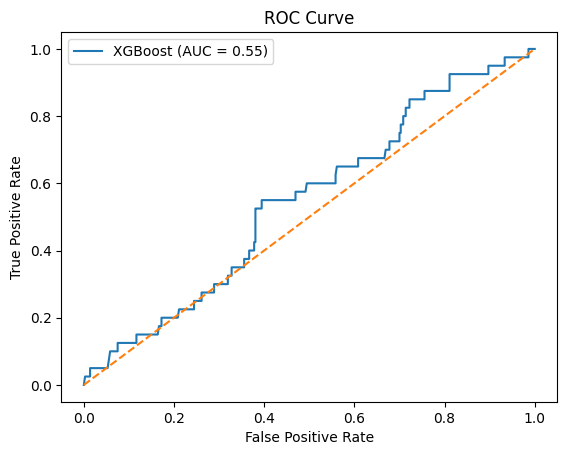

In [102]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probabilities
y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [103]:
import numpy as np

threshold = 0.3  # try lower than 0.5

y_pred_custom = (y_prob > threshold).astype(int)

In [104]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[270  90]
 [ 30  10]]
              precision    recall  f1-score   support

           0       0.90      0.75      0.82       360
           1       0.10      0.25      0.14        40

    accuracy                           0.70       400
   macro avg       0.50      0.50      0.48       400
weighted avg       0.82      0.70      0.75       400

